In [1]:
import numpy as np
from matplotlib.pyplot import*
from scipy import stats as st
from scipy import optimize as op
from scipy import fftpack
from scipy import signal
from scipy.special import erf
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.collections import PolyCollection
from scipy.integrate import *
%matplotlib inline   
from statistics import *

In [2]:
Nx=100;Ny=100
deltax=1./Nx;deltay=1./Ny
deltat=.05*(deltay**2)

d=2# durée de l'évolution
Nt=int(d/deltat) # nombre de pas de temps
Ne=Nt//100

xx=np.linspace(0,1,Nx+1)
yy=np.linspace(0,1,Ny+1)
t=np.linspace(0,1,Ne+1)
y,x=np.meshgrid(yy,xx)
#x,y=np.meshgrid(xx,yy)
inclusion=[]
for i in range(Nx+1):
    inclusion.append([False]*(Nx+1))
theta=np.zeros((Nx+1,Ny+1)) 
theta_e=np.zeros((Nx+1,Ny+1,Ne+1)) # pour échantilloner et avoir accés au champ de température à chaque instant échantilloné

x1=.5    #parametres géométriques de la bulle
y1=.5
r=.1

for i in range(1,4):
    for j in range(1,4):
        x1=i/4
        y1=j/4
        inclusion=np.bitwise_or(inclusion,(x-x1)**2+(y-y1)**2<=r**2)

#matrices de conductivité, masses volumiqes et capacité thermiques massiques
kappa=x*0+1
mu=x*0+1
c=x*0+1

#inclusion=(x-x1)**2+(y-y1)**2<=r**2

#on superpose au tableau des valeurs le tableau inclusion
kappa[inclusion]=1.e-1
mu[inclusion]=1.
c[inclusion]=1.

muc=mu*c                                                      
                                #deux disques
inclusion=[]
for i in range(Nx+1):
    inclusion.append([False]*(Nx+1))
    
#inclusion=np.bitwise_or((x-x1)**2+(y-y1)**2<=r**2,(x-x2)**2+(y-y2)**2<=r**2)
#print(inclusion)
#inclusion=np.array(([False]*Nx) for i in range(Nx))

        
#for i in range(1,4):
 #   y1=i/4
  #  inclusion=np.bitwise_or(inclusion,(x-x1)**2+(y-y1)**2<=r**2)
    


# faire des conditions pour pouvoir générer aléatoirement plusieurs inclusions 

#disque
#inclusion=(x-x1)**2+(y-y1)**2<=r**2


#bande
#inclusion=np.bitwise_and(y<=y1,y>=x1)
#inclusion=np.bitwise_and(np.bitwise_and(y<=y1,y>=-y1),x<=x1)
#cuivre=np.bitwise_and(np.bitwise_and(y<=y1,y>=-y1),x>x1)

# placement des bulles sous forme de maille 

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres de la grille
Nx = 100
Ny = 100
deltax = 1. / Nx
deltay = 1. / Ny
deltat = .05 * (deltay ** 2)

d = 2  # Durée de l'évolution
Nt = int(d / deltat)  # Nombre de pas de temps
Ne = Nt // 100

xx = np.linspace(0, 1, Nx + 1)
yy = np.linspace(0, 1, Ny + 1)
t = np.linspace(0, 1, Ne + 1)
y, x = np.meshgrid(yy, xx)

theta=np.zeros((Nx+1,Ny+1)) 
theta_e=np.zeros((Nx+1,Ny+1,Ne+1))

# Paramètres de maille et des bulles
a = 0.5  # Espacement entre les bulles
r = 0.1  # Rayon des bulles

# Calcul du nombre de bulles par ligne/colonne
num_bubbles_x = int(1 / a) + 1
num_bubbles_y = int(1 / a) + 1

# Calcul des décalages pour centrer la grille
offset_x = (1 - (num_bubbles_x - 1) * a) / 2
offset_y = (1 - (num_bubbles_y - 1) * a) / 2

# Initialisation des inclusions
inclusion = np.zeros((Nx + 1, Ny + 1), dtype=bool)

# Positionner les bulles sur une grille régulière centrée
for i in range(num_bubbles_x):
    for j in range(num_bubbles_y):
        x1 = offset_x + i * a
        y1 = offset_y + j * a
        inclusion |= (x - x1) ** 2 + (y - y1) ** 2 <= r ** 2

# Matrices de conductivité, masses volumiques et capacité thermiques massiques
kappa = np.ones((Nx + 1, Ny + 1))
mu = np.ones((Nx + 1, Ny + 1))
c = np.ones((Nx + 1, Ny + 1))

# Superposition des valeurs des inclusions
kappa[inclusion] = 0.15
mu[inclusion] = 1
c[inclusion] = 1

muc = mu * c

0.1349


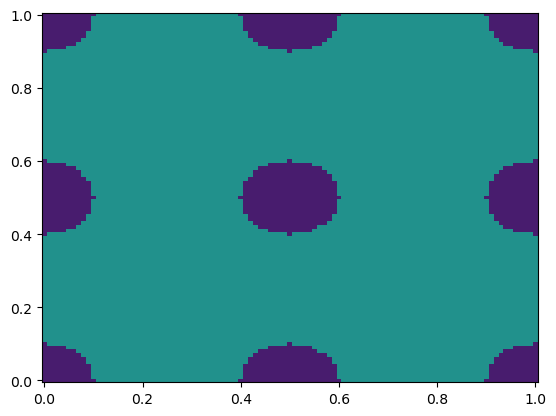

In [9]:
pcolormesh(xx,yy,kappa, vmin=0, vmax=2)
savefig("inclusions néoprène 2D")

In [12]:
for j in range(Nt):
    theta[1:-1,1:-1]+=1./muc[1:-1,1:-1]*(deltat/deltax*((theta[2:,1:-1]-theta[1:-1,1:-1])*kappa[2:,1:-1]/deltax
                                                    +(theta[:-2,1:-1]-theta[1:-1,1:-1])*kappa[1:-1,1:-1]/deltax)
                                        +deltat/deltay*((theta[1:-1,2:]-theta[1:-1,1:-1])*kappa[1:-1,2:]/deltay
                                                    +(theta[1:-1,:-2]-theta[1:-1,1:-1])*kappa[1:-1,1:-1]/deltay))
    #C.L.
    theta[0,::]=theta[1,::]
    theta[Nx,::]=theta[Nx-1,::]
    theta[::,0]=1 
    theta[::,Ny]=0
    if j%100==0: 
        theta_e[:,:,j//100]=theta[:,:]
flux=-np.sum(kappa[:,1:]*(theta_e[:,1:,3999]-theta_e[:,:-1,3999]),axis=0)

399999


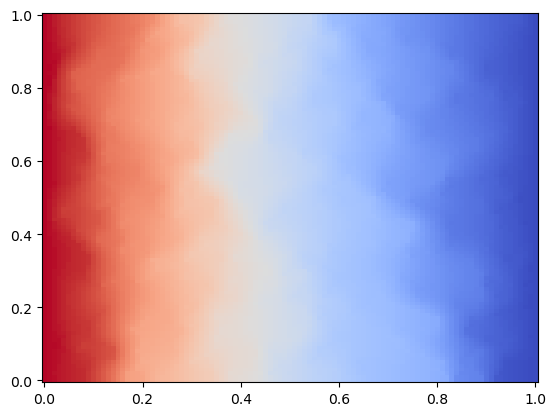

In [185]:
pcolormesh(xx,yy,theta_e[:,:,1000],cmap='coolwarm')

savefig("1 bulle")

In [186]:
L = 3e-3
kc = 0.37
flux=-np.sum(kappa[:,1:]*(theta_e[:,1:,3999]-theta_e[:,:-1,3999]),axis=0)
print(type(j))
rth = L / (kc *flux[10])
#plot(xx[:-1],j)
#theta_e[1:,:,50]-theta_e[:-1,:,50]
print("j = ",flux,"\n","variance =",pvariance(flux),"ecart type =",stdev(flux))
print(rth)

<class 'numpy.ndarray'>
j =  [0.51360264 0.51360695 0.51342247 0.51304511 0.51297925 0.5128756
 0.51260963 0.51213674 0.52493248 0.51148623 0.51141515 0.51133111
 0.51128314 0.51131376 0.51145996 0.51177186 0.51232182 0.51301866
 0.51433229 0.51460466 0.51195505 0.50988773 0.50532517 0.50558011
 0.50758573 0.50888072 0.50990744 0.5106635  0.51133629 0.51341188
 0.51376882 0.51215531 0.50861142 0.50694708 0.50489509 0.50445345
 0.50398089 0.50343057 0.51127239 0.5078273  0.51016501 0.5119925
 0.51397773 0.5166874  0.52145278 0.52137851 0.52011921 0.51696523
 0.51556993 0.51497737 0.51450528 0.51386889 0.51299731 0.51187556
 0.53369922 0.51011706 0.50987003 0.53962248 0.5120356  0.51257889
 0.51685431 0.51832861 0.51872609 0.51811107 0.51677069 0.5141839
 0.51297794 0.51263921 0.51285634 0.51341344 0.51401314 0.51412259
 0.51370563 0.51324874 0.51295879 0.51287545 0.51296921 0.513195
 0.51353573 0.51407452 0.5150863  0.51678372 0.55845153 0.55729664
 0.51607694 0.51543454 0.51407209 0.51

# Boucle pour tracer la rth en fonction du paramètre de maille 

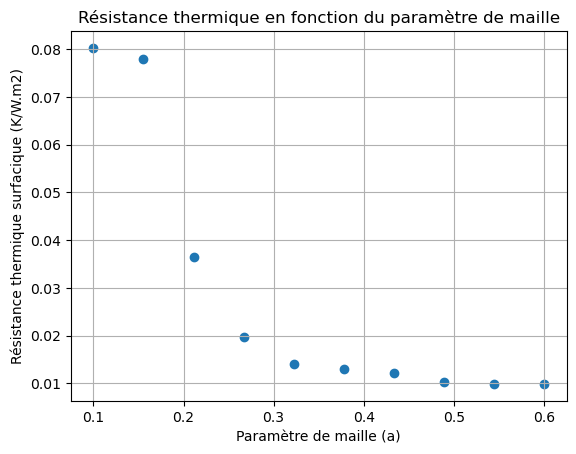

In [414]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres de la grille
Nx = 100
Ny = 100
deltax = 1. / Nx
deltay = 1. / Ny
deltat = .05 * (deltay ** 2)

d = 2  # Durée de l'évolution
Nt = int(d / deltat)  # Nombre de pas de temps
Ne = Nt // 100

# Définir une plage de valeurs pour le paramètre de maille a
a_values = np.linspace(0.1, 0.6, 10)  # Par exemple, de 0.1 à 0.9 avec 9 valeurs

# Liste pour stocker les résistances thermiques calculées
rth_values = []

# Pour chaque valeur de paramètre de maille
for a in a_values:
    # Grille de points
    xx = np.linspace(0, 1, Nx + 1)
    yy = np.linspace(0, 1, Ny + 1)
    y, x = np.meshgrid(yy, xx)

    # Calcul des décalages pour centrer la grille en fonction de a
    num_bubbles_x = int(1 / a) + 1
    num_bubbles_y = int(1 / a) + 1
    offset_x = (1 - (num_bubbles_x - 1) * a) / 2
    offset_y = (1 - (num_bubbles_y - 1) * a) / 2

    # Initialisation des inclusions
    inclusion = np.zeros((Nx + 1, Ny + 1), dtype=bool)

    # Positionner les bulles sur une grille régulière centrée
    for i in range(num_bubbles_x):
        for j in range(num_bubbles_y):
            x1 = offset_x + i * a
            y1 = offset_y + j * a
            inclusion |= (x - x1) ** 2 + (y - y1) ** 2 <= r ** 2

    # Matrices de conductivité, masses volumiques et capacité thermiques massiques
    kappa = np.ones((Nx + 1, Ny + 1))
    mu = np.ones((Nx + 1, Ny + 1))
    c = np.ones((Nx + 1, Ny + 1))

    # Superposition des valeurs des inclusions
    kappa[inclusion] = 1.e-1
    mu[inclusion] = 1.
    c[inclusion] = 1.

    muc = mu * c

    # Initialisation du champ de température
    theta = np.zeros((Nx + 1, Ny + 1))

    # Simulation de la diffusion de chaleur
    for j in range(Nt):
        theta[1:-1,1:-1] += (1. / muc[1:-1,1:-1] * (deltat / deltax * 
                        ((theta[2:,1:-1] - theta[1:-1,1:-1]) * kappa[2:,1:-1] / deltax +
                         (theta[:-2,1:-1] - theta[1:-1,1:-1]) * kappa[1:-1,1:-1] / deltax) +
                         deltat / deltay * 
                        ((theta[1:-1,2:] - theta[1:-1,1:-1]) * kappa[1:-1,2:] / deltay +
                         (theta[1:-1,:-2] - theta[1:-1,1:-1]) * kappa[1:-1,1:-1] / deltay)))
        
        # Boundary conditions
        theta[0, :] = theta[1, :]
        theta[Nx, :] = theta[Nx-1, :]
        theta[:, 0] = 1  # Adiabatic wall on the left
        theta[:, Ny] = 0 # Adiabatic wall on the right
        
        if j % 100 == 0:
            theta_e[:, :, j//100] = theta[:, :]
    
    j_value = -np.sum(kappa[:, 1:] * (theta_e[:, 1:, Ne] - theta_e[:, :-1, Ne]), axis=0)
    j_mean = np.mean(j_value)
    
    # Calcul de la résistance thermique pour cette valeur de a
    rth = L / (kc * j_mean)

    # Ajouter la résistance thermique à la liste
    rth_values.append(rth)

plt.scatter(a_values, rth_values, marker='o')
plt.xlabel('Paramètre de maille (a)')
plt.ylabel('Résistance thermique surfacique (K/W.m2)')
plt.title('Résistance thermique en fonction du paramètre de maille')
plt.grid(True)
plt.show()



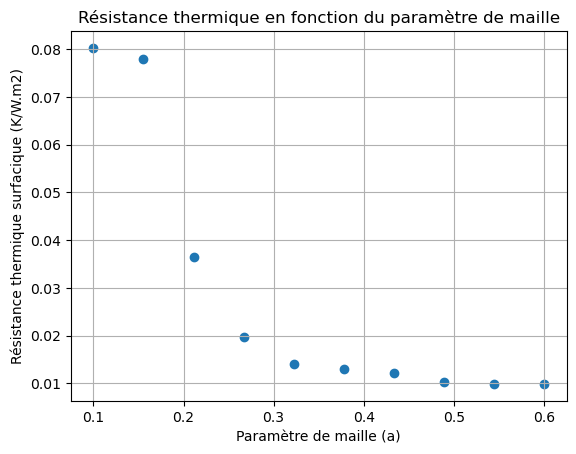

<Figure size 640x480 with 0 Axes>

In [416]:
plt.scatter(a_values, rth_values, marker='o')
plt.xlabel('Paramètre de maille (a)')
plt.ylabel('Résistance thermique surfacique (K/W.m2)')
plt.title('Résistance thermique en fonction du paramètre de maille')
plt.grid(True)
plt.show()
savefig('paramètre de maille')

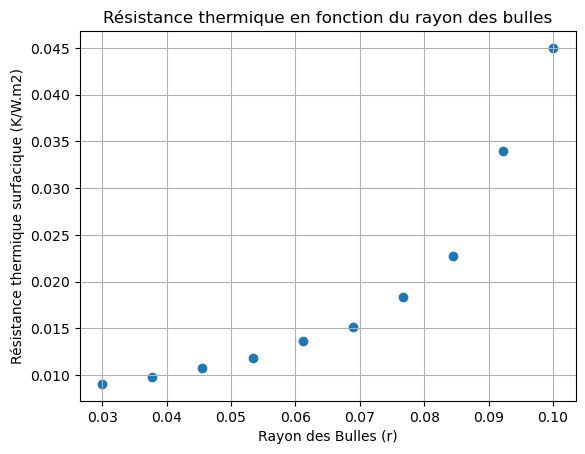

In [457]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres de la grille
Nx = 100
Ny = 100
deltax = 1. / Nx
deltay = 1. / Ny
deltat = .05 * (deltay ** 2)

d = 2  # Durée de l'évolution
Nt = int(d / deltat)  # Nombre de pas de temps
Ne = Nt // 100

# Définir une plage de valeurs pour le paramètre de maille a
r_values = np.linspace(0.03, 0.1, 10)  # Par exemple, de 0.1 à 0.9 avec 9 valeurs
a=0.2
# Liste pour stocker les résistances thermiques calculées
rth_values = []

# Pour chaque valeur de paramètre de maille
for r in r_values:
    # Grille de points
    xx = np.linspace(0, 1, Nx + 1)
    yy = np.linspace(0, 1, Ny + 1)
    y, x = np.meshgrid(yy, xx)

    # Calcul des décalages pour centrer la grille en fonction de a
    num_bubbles_x = int(1 / a) + 1
    num_bubbles_y = int(1 / a) + 1
    offset_x = (1 - (num_bubbles_x - 1) * a) / 2
    offset_y = (1 - (num_bubbles_y - 1) * a) / 2

    # Initialisation des inclusions
    inclusion = np.zeros((Nx + 1, Ny + 1), dtype=bool)

    # Positionner les bulles sur une grille régulière centrée
    for i in range(num_bubbles_x):
        for j in range(num_bubbles_y):
            x1 = offset_x + i * a
            y1 = offset_y + j * a
            inclusion |= (x - x1) ** 2 + (y - y1) ** 2 <= r ** 2

    # Matrices de conductivité, masses volumiques et capacité thermiques massiques
    kappa = np.ones((Nx + 1, Ny + 1))
    mu = np.ones((Nx + 1, Ny + 1))
    c = np.ones((Nx + 1, Ny + 1))

    # Superposition des valeurs des inclusions
    kappa[inclusion] = 1.e-1
    mu[inclusion] = 1.
    c[inclusion] = 1.

    muc = mu * c

    # Initialisation du champ de température
    theta = np.zeros((Nx + 1, Ny + 1))

    # Simulation de la diffusion de chaleur
    for j in range(Nt):
        theta[1:-1,1:-1] += (1. / muc[1:-1,1:-1] * (deltat / deltax * 
                        ((theta[2:,1:-1] - theta[1:-1,1:-1]) * kappa[2:,1:-1] / deltax +
                         (theta[:-2,1:-1] - theta[1:-1,1:-1]) * kappa[1:-1,1:-1] / deltax) +
                         deltat / deltay * 
                        ((theta[1:-1,2:] - theta[1:-1,1:-1]) * kappa[1:-1,2:] / deltay +
                         (theta[1:-1,:-2] - theta[1:-1,1:-1]) * kappa[1:-1,1:-1] / deltay)))
        
        # Boundary conditions
        theta[0, :] = theta[1, :]
        theta[Nx, :] = theta[Nx-1, :]
        theta[:, 0] = 1  # Adiabatic wall on the left
        theta[:, Ny] = 0 # Adiabatic wall on the right
        
        if j % 100 == 0:
            theta_e[:, :, j//100] = theta[:, :]
    
    j_value = -np.sum(kappa[:, 1:] * (theta_e[:, 1:, Ne] - theta_e[:, :-1, Ne]), axis=0)
    j_mean = np.mean(j_value)
    
    # Calcul de la résistance thermique pour cette valeur de a
    rth = L / (kc * j_mean)

    # Ajouter la résistance thermique à la liste
    rth_values.append(rth)

plt.scatter(r_values, rth_values, marker='o')
plt.xlabel('Rayon des Bulles (r)')
plt.ylabel('Résistance thermique surfacique (K/W.m2)')
plt.title('Résistance thermique en fonction du rayon des bulles')
plt.grid(True)
plt.show()



In [367]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres de la grille
Nx = 100
Ny = 100
deltax = 1. / Nx
deltay = 1. / Ny
deltat = .05 * (deltay ** 2)

d = 2  # Durée de l'évolution
Nt = int(d / deltat)  # Nombre de pas de temps
Ne = Nt // 100

# Grille de points
xx = np.linspace(0, 1, Nx + 1)
yy = np.linspace(0, 1, Ny + 1)
t = np.linspace(0, 1, Ne + 1)
y, x = np.meshgrid(yy, xx)

# Paramètres de maille et des bulles
a = 0.25  # Espacement entre les bulles
r = 0.1   # Rayon des bulles

# Calcul du nombre de bulles par ligne/colonne
num_bubbles_x = int(1 / a) + 1
num_bubbles_y = int(1 / a) + 1

# Calcul des décalages pour centrer la grille
offset_x = (1 - (num_bubbles_x - 1) * a) / 2
offset_y = (1 - (num_bubbles_y - 1) * a) / 2

# Initialisation des inclusions
inclusion = np.zeros((Nx + 1, Ny + 1), dtype=bool)

# Positionner les bulles sur une grille régulière centrée
for i in range(num_bubbles_x):
    for j in range(num_bubbles_y):
        x1 = offset_x + i * a
        y1 = offset_y + j * a
        inclusion |= (x - x1) ** 2 + (y - y1) ** 2 <= r ** 2

# Matrices de conductivité, masses volumiques et capacité thermiques massiques
kappa = np.ones((Nx + 1, Ny + 1))
mu = np.ones((Nx + 1, Ny + 1))
c = np.ones((Nx + 1, Ny + 1))

# Superposition des valeurs des inclusions
kappa[inclusion] = 1.e-1
mu[inclusion] = 1.
c[inclusion] = 1.

muc = mu * c

# Initialisation du champ de température
theta = np.zeros((Nx + 1, Ny + 1))
theta_e = np.zeros((Nx + 1, Ny + 1, Ne + 1))

# Simulation de la diffusion de chaleur
print(Nt)
for j in range(Nt):
    theta[1:-1, 1:-1] += 1. / muc[1:-1, 1:-1] * (
        deltat / deltax * (
            (theta[2:, 1:-1] - theta[1:-1, 1:-1]) * kappa[2:, 1:-1] / deltax +
            (theta[:-2, 1:-1] - theta[1:-1, 1:-1]) * kappa[1:-1, 1:-1] / deltax
        ) + deltat / deltay * (
            (theta[1:-1, 2:] - theta[1:-1, 1:-1]) * kappa[1:-1, 2:] / deltay +
            (theta[1:-1, :-2] - theta[1:-1, 1:-1]) * kappa[1:-1, 1:-1] / deltay
        )
    )
    # Conditions aux limites
    theta[0, :] = theta[1, :]  # Paroi adiabatique en haut
    theta[Nx, :] = theta[Nx - 1, :]  # Paroi adiabatique en bas
    theta[:, 0] = 1  # Paroi à gauche avec température fixée à 1
    theta[:, Ny] = 0  # Paroi à droite avec température fixée à 0

    if j % 100 == 0:
        theta_e[:, :, j // 100] = theta[:, :]


399999


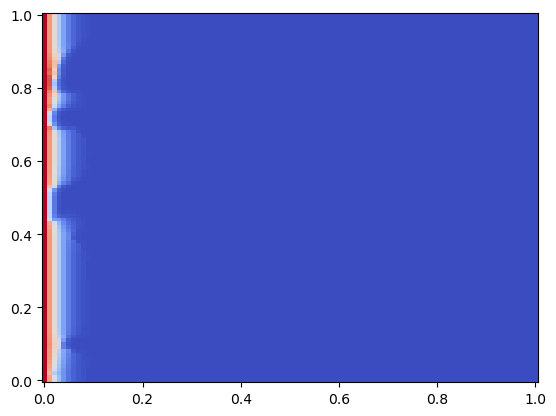

In [184]:
pcolormesh(xx,yy,theta_e[:,:,1],cmap='coolwarm')
j=-np.sum(kappa[:,1:]*(theta_e[:,1:,3999]-theta_e[:,:-1,3999]),axis=0)

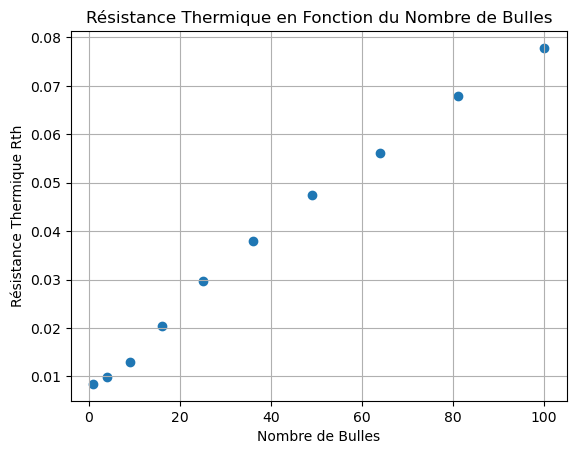

In [418]:
import numpy as np
import matplotlib.pyplot as plt

# Define grid and time step parameters
Nx, Ny = 100, 100
deltax, deltay = 1./Nx, 1./Ny
deltat = .05 * (deltay**2)
d = 2  # Duration of evolution
Nt = int(d / deltat)  # Number of time steps
Ne = Nt // 100

# Define spatial grid
xx = np.linspace(0, 1, Nx + 1)
yy = np.linspace(0, 1, Ny + 1)
y, x = np.meshgrid(yy, xx)

# Parameters for bubble
r = 0.1

# Constants for thermal resistance calculation
L = 3e-3
kc = 0.37

# Initialize arrays to store results
num_bubbles_list = []
rth_values = []

# Function to initialize thermal properties
def initialize_properties(num_bubbles):
    inclusion = np.zeros((Nx+1, Ny+1), dtype=bool)
    for i in range(1, num_bubbles+1):
        for j in range(1, num_bubbles+1):
            x1, y1 = i / (num_bubbles + 1), j / (num_bubbles + 1)
            inclusion = np.bitwise_or(inclusion, (x - x1)**2 + (y - y1)**2 <= r**2)

    kappa = np.ones((Nx+1, Ny+1))
    mu = np.ones((Nx+1, Ny+1))
    c = np.ones((Nx+1, Ny+1))
    
    kappa[inclusion] = 0.1
    mu[inclusion] = 1.0
    c[inclusion] = 1.0
    
    return kappa, mu, c

# Loop over different numbers of bubbles
for num_bubbles in range(1, 11):  # Adjust to get 10 different values
    kappa, mu, c = initialize_properties(num_bubbles)
    muc = mu * c
    theta = np.zeros((Nx+1, Ny+1))
    theta_e = np.zeros((Nx+1, Ny+1, Ne+1))
    
    # Time evolution
    for j in range(Nt):
        theta[1:-1,1:-1] += (1. / muc[1:-1,1:-1] * (deltat / deltax * 
                        ((theta[2:,1:-1] - theta[1:-1,1:-1]) * kappa[2:,1:-1] / deltax +
                         (theta[:-2,1:-1] - theta[1:-1,1:-1]) * kappa[1:-1,1:-1] / deltax) +
                         deltat / deltay * 
                        ((theta[1:-1,2:] - theta[1:-1,1:-1]) * kappa[1:-1,2:] / deltay +
                         (theta[1:-1,:-2] - theta[1:-1,1:-1]) * kappa[1:-1,1:-1] / deltay)))
        
        # Boundary conditions
        theta[0, :] = theta[1, :]
        theta[Nx, :] = theta[Nx-1, :]
        theta[:, 0] = 1  # Adiabatic wall on the left
        theta[:, Ny] = 0 # Adiabatic wall on the right
        
        if j % 100 == 0:
            theta_e[:, :, j//100] = theta[:, :]
    
    j_value = -np.sum(kappa[:, 1:] * (theta_e[:, 1:, Ne] - theta_e[:, :-1, Ne]), axis=0)
    j_mean = np.mean(j_value)
    
    # Calculate thermal resistance
    rth = L / (kc * j_mean)
    
    num_bubbles_list.append(num_bubbles**2)
    rth_values.append(rth)

# Plotting the results
plt.scatter(num_bubbles_list, rth_values, marker='o')
plt.xlabel('Nombre de Bulles')
plt.ylabel('Résistance Thermique Rth')
plt.title('Résistance Thermique en Fonction du Nombre de Bulles')
plt.grid(True)
plt.show()



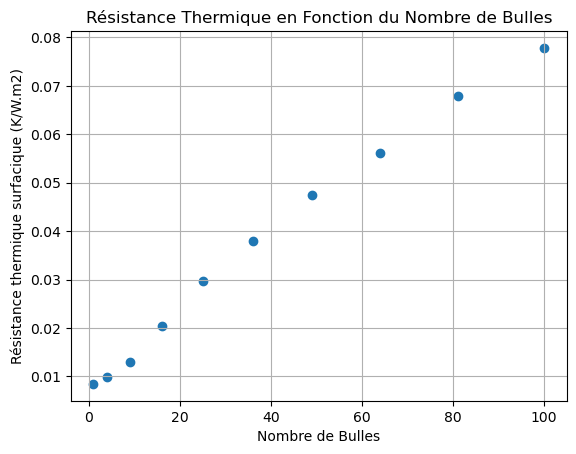

In [420]:
plt.scatter(num_bubbles_list, rth_values, marker='o')
plt.xlabel('Nombre de Bulles')
plt.ylabel('Résistance thermique surfacique (K/W.m2)')
plt.title('Résistance Thermique en Fonction du Nombre de Bulles')
plt.grid(True)
plt.show()


In [63]:
plt.scatter(num_bubbles_list, rth_values, marker='o')
plt.xlabel('Nombre de bulles')
plt.ylabel('Résistance thermqique Rth')
plt.title('Resistance thermique en fonction du nombre de bulles à rayon constant')
plt.grid(True)
savefig('graphe')
plt.show()


NameError: name 'num_bubbles_list' is not defined

# Approche statistique du nombre de bulle de leur repartition et du rayon 

0.8235

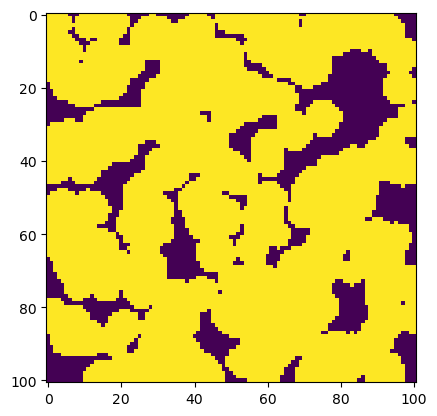

In [316]:
rv1=st.norm(loc=.05,scale=0.01)
rv2=st.uniform(0,1)

Nx=100;Ny=100
deltax=1./Nx;deltay=1./Ny
deltat=.05*(deltay**2)

d=.2 # durée de l'évolution
Nt=int(d/deltat) # nombre de pas de temps


xx=np.linspace(0,1,Nx+1)
yy=np.linspace(0,1,Ny+1)
y,x=np.meshgrid(yy,xx)


cond=x<-1
Nb=200
yc=rv2.rvs(Nb)
xc=rv2.rvs(Nb)
rc=rv1.rvs(Nb)

#plot(xc,yc,'ro')
savefig("placement des points")

for i in range(Nb): 
    bulle=(x-xc[i])**2+(y-yc[i])**2<=rc[i]**2 
    cond=np.bitwise_or(cond,bulle)
imshow(cond)
savefig("approche statistique") 
fraction=x*0
fraction[cond]=1
np.sum(np.sum(fraction,axis=0),axis=0)/(Nx*Ny)


# Placement aléatoire sans que les bulles ne se chevauchent 

In [333]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, uniform

rv1 = norm(loc=0.05, scale=0.01)  # Distribution normale pour les rayons des bulles
rv2 = uniform(0, 1)  # Distribution uniforme pour les positions des centres des bulles

Nx = 100
Ny = 100
deltax = 1.0 / Nx
deltay = 1.0 / Ny
deltat = 0.05 * (deltay ** 2)

d = 0.2
Nt = int(d / deltat)

xx = np.linspace(0, 1, Nx + 1)
yy = np.linspace(0, 1, Ny + 1)
y, x = np.meshgrid(yy, xx)

cond = x < -1
Nb = 200
yc = np.zeros(Nb)
xc = np.zeros(Nb)
rc = np.zeros(Nb)

def is_overlapping(xc, yc, rc, new_x, new_y, new_r):
    for i in range(len(xc)):
        if xc[i] == 0 and yc[i] == 0 and rc[i] == 0:
            continue
        distance = np.sqrt((xc[i] - new_x) ** 2 + (yc[i] - new_y) ** 2)
        if distance < (rc[i] + new_r):
            return True
    return False

max_attempts = 1000  # Nombre maximum d'essais pour placer une bulle
target_coverage = 0.8  # Taux d'occupation cible
current_coverage = 0.0

for i in range(Nb):
    attempts = 0
    while attempts < max_attempts:
        new_x = rv2.rvs()
        new_y = rv2.rvs()
        new_r = rv1.rvs()
        if not is_overlapping(xc, yc, rc, new_x, new_y, new_r):
            xc[i] = new_x
            yc[i] = new_y
            rc[i] = new_r
            break
        attempts += 1
    if attempts == max_attempts:
        print(f"Could not place bubble {i} after {max_attempts} attempts.")
    
    # Mise à jour du taux d'occupation
    for j in range(i + 1):
        bulle = (x - xc[j])**2 + (y - yc[j])**2 <= rc[j]**2
        cond = np.bitwise_or(cond, bulle)
    fraction = np.zeros_like(x)
    fraction[cond] = 1
    current_coverage = np.sum(fraction) / (Nx * Ny)
    
    if current_coverage >= target_coverage:
        print(f"Target coverage of {target_coverage} reached with {i + 1} bubbles.")
        break

plt.figure()
plt.plot(xc[:i+1], yc[:i+1], 'ro')
plt.title("Placement des points")
plt.savefig("placement_des_points.png")
plt.close()

plt.figure()
plt.imshow(cond, origin='lower', extent=(0, 1, 0, 1))
plt.title("Approche statistique")
plt.savefig("approche_statistique.png")
plt.close()

print("Fraction of grid covered by bubbles:", current_coverage)


Could not place bubble 94 after 1000 attempts.
Could not place bubble 96 after 1000 attempts.
Could not place bubble 100 after 1000 attempts.
Could not place bubble 101 after 1000 attempts.
Could not place bubble 102 after 1000 attempts.
Could not place bubble 105 after 1000 attempts.
Could not place bubble 106 after 1000 attempts.
Could not place bubble 108 after 1000 attempts.
Could not place bubble 109 after 1000 attempts.
Could not place bubble 111 after 1000 attempts.
Could not place bubble 114 after 1000 attempts.
Could not place bubble 116 after 1000 attempts.
Could not place bubble 117 after 1000 attempts.
Could not place bubble 118 after 1000 attempts.
Could not place bubble 119 after 1000 attempts.
Could not place bubble 120 after 1000 attempts.
Could not place bubble 122 after 1000 attempts.
Could not place bubble 128 after 1000 attempts.
Could not place bubble 129 after 1000 attempts.
Could not place bubble 130 after 1000 attempts.
Could not place bubble 131 after 1000 atte

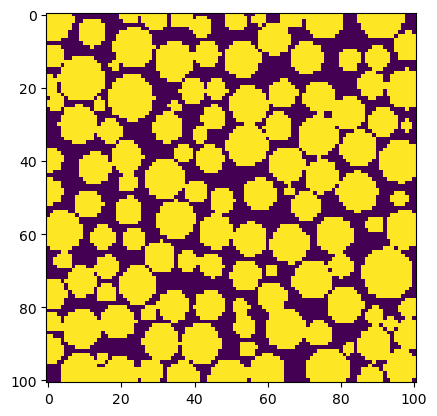

In [334]:
imshow(cond)

# Résolution de l'équation de la chaleur sur la grille cond 

In [318]:
deltax=1./Nx;deltay=1./Ny
deltat=.05*(deltay**2)

d=2# durée de l'évolution
Nt=int(d/deltat) # nombre de pas de temps
Ne=Nt//100

xx=np.linspace(0,1,Nx+1)
yy=np.linspace(0,1,Ny+1)
t=np.linspace(0,1,Ne+1)
y,x=np.meshgrid(yy,xx)
#x,y=np.meshgrid(xx,yy)

theta=np.zeros((Nx+1,Ny+1)) 
theta_e=np.zeros((Nx+1,Ny+1,Ne+1)) 

mu=x*0+1
c=x*0+1
kappa=x*0+1
#on superpose au tableau 
#des valeurs le tableau inclusion
kappa[cond]=0.1
mu[cond]=1.
c[cond]=1


muc=mu*c


In [319]:
#RS=False
print(Nt)
for j in range(Nt):
    theta[1:-1,1:-1]+=1./muc[1:-1,1:-1]*(deltat/deltax*((theta[2:,1:-1]-theta[1:-1,1:-1])*kappa[2:,1:-1]/deltax
                                                        +(theta[:-2,1:-1]-theta[1:-1,1:-1])*kappa[1:-1,1:-1]/deltax)
                                         +deltat/deltay*((theta[1:-1,2:]-theta[1:-1,1:-1])*kappa[1:-1,2:]/deltay
                                                         +(theta[1:-1,:-2]-theta[1:-1,1:-1])*kappa[1:-1,1:-1]/deltay))
    #C.L.
    theta[0,::]=theta[1,::]
    theta[Nx,::]=theta[Nx-1,::]
    theta[::,0]=1 
    theta[::,Ny]=0
    if j%100==0: 
        theta_e[:,:,j//100]=theta[:,:]
        


399999


0.05097864996255012


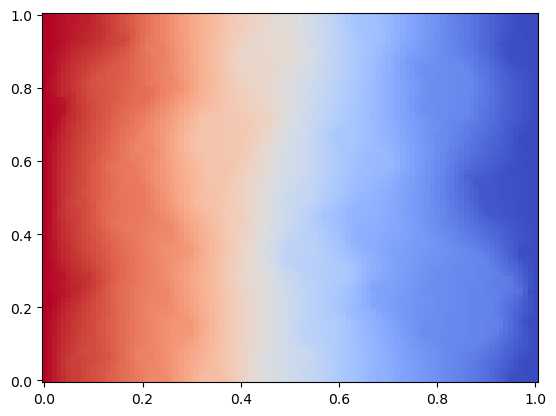

In [322]:
pcolormesh(xx,yy,theta_e[:,:,3999],cmap='coolwarm')
#j=np.sum(kappa[1:,:]*(theta_e[1:,:,2499]-theta_e[:-1,:,2499]),axis=0)
flux=-np.sum(kappa[:,1:]*(theta_e[:,1:,3999]-theta_e[:,:-1,3999]),axis=0)
rth = L / (kc *mean(flux))
#print(flux)
print(rth)

# Partie du programme à revoir 

-0.4952515946010383
-0.30241318209291995
-0.2409150111936183
-0.2823558587346269
-0.27332020363353215
-0.2834143611149335
-0.2792960533589728
-0.27582045921471954
-0.1866111386387484
-0.1864873282287004
-0.18566500466607835
-0.18565718699849285
-0.18565718699849285
-0.1870812182401526
-0.18707607609219928
-0.18707607609219928
-0.18707607609219928
-0.18707607609219928
-0.18707607609219928
-0.18707607609219928
-0.18707607609219928
-0.18707607609219928
-0.18707607609219928
-0.18707607609219928
-0.18707607609219928
-0.18707607609219928
-0.18707607609219928
-0.18707607609219928
-0.18707607609219928
-0.18707607609219928
[-0.4952515946010383, -0.30241318209291995, -0.2409150111936183, -0.2823558587346269, -0.27332020363353215, -0.2834143611149335, -0.2792960533589728, -0.27582045921471954, -0.1866111386387484, -0.1864873282287004, -0.18566500466607835, -0.18565718699849285, -0.18565718699849285, -0.1870812182401526, -0.18707607609219928, -0.18707607609219928, -0.18707607609219928, -0.18707607

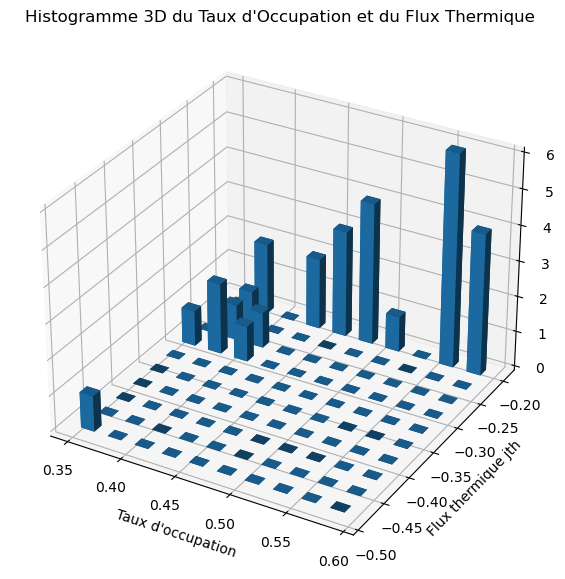

In [3]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Paramètres de la grille
Nx = 20
Ny = 20
deltax = 1. / Nx
deltay = 1. / Ny
deltat = .2 * (deltay ** 2)
d = 1.  # durée de l'évolution
Nt = int(d / deltat)  # nombre de pas de temps
Ne=10

xx = np.linspace(0, 1, Nx + 1)
yy = np.linspace(0, 1, Ny + 1)
t = np.linspace(0, 1, Ne + 1)
y, x = np.meshgrid(yy, xx)

jth = []
occupation = []

# Initialisation des paramètres des matériaux
kappa = x * 0 + 1
mu = x * 0 + 1
c = x * 0 + 1

simulation=10
conds=[]
for i in range(3,6):
    for sim in range(simulation):
        rv1 = st.expon(loc=.02, scale=.01)
        rv2 = st.uniform(0, 1)
        cond = x < -1
        Nb = i * 50
        yc = rv2.rvs(Nb)
        xc = rv2.rvs(Nb)
        rc = rv1.rvs(Nb)
        
        for l in range(Nb):
            bulle = (x - xc[l]) ** 2 + (y - yc[l]) ** 2 <= rc[l] ** 2
            cond = np.bitwise_or(cond, bulle)
        conds.append(cond)
        
        fraction = x * 0
        fraction[cond] = 1
        theta = np.zeros((Nx + 1, Ny + 1))
        theta_e = np.zeros((Nx + 1, Ny + 1, Ne + 1))
        
        # Mise à jour des paramètres des inclusions
        kappa[cond] = 0.1
        mu[cond] = 1.
        c[cond] = 1.
        muc = mu * c
        
        # Simulation de l'évolution de la température
        for r in range(Nt):
            theta[1:-1, 1:-1] += 1. / muc[1:-1, 1:-1] * (
                deltat / deltax * ((theta[2:, 1:-1] - theta[1:-1, 1:-1]) * kappa[2:, 1:-1] / deltax
                + (theta[:-2, 1:-1] - theta[1:-1, 1:-1]) * kappa[1:-1, 1:-1] / deltax)
                + deltat / deltay * ((theta[1:-1, 2:] - theta[1:-1, 1:-1]) * kappa[1:-1, 2:] / deltay
                + (theta[1:-1, :-2] - theta[1:-1, 1:-1]) * kappa[1:-1, 1:-1] / deltay))
            
            # Conditions aux limites
            theta[0, :] = 1
            theta[Nx, :] = 0
            theta[:, 0] = theta[:, 1]
            theta[:, Ny] = theta[:, Ny - 1]
            if r==Nt-1:
                jth_value = np.sum(kappa[1:,:]*(theta[1:, :] - theta[:-1, :]), axis=1)[0]
                print(jth_value)
                jth.append(jth_value)
            
 #           if r % (Nt//Ne) == 0:
 #               theta_e[:, :, r // (Nt//Ne)] = theta[:, :]
        
        
        occupation_value = np.sum(fraction) / (Nx * Ny)
        
        #jth.append(jth_value)
        occupation.append(occupation_value)

# Affichage des résultats
print(jth)
print(occupation)

# Création de l'histogramme 3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Nombre de bins pour les axes
num_bins = 10

# Calcul de l'histogramme
hist, xedges, yedges = np.histogram2d(occupation, jth, bins=num_bins)

# Créer les positions pour les barres du graphique 3D
xpos, ypos = np.meshgrid(xedges[:-1] + 0.25 * (xedges[1] - xedges[0]),
                         yedges[:-1] + 0.25 * (yedges[1] - yedges[0]),
                         indexing="ij")

xpos = xpos.ravel()
ypos = ypos.ravel()
zpos = np.zeros_like(xpos)

# Hauteur des barres
dx = dy = 0.5 * (xedges[1] - xedges[0])
dz = hist.ravel()

ax.bar3d(xpos, ypos, zpos, dx, dy, dz, zsort='average')

# Labels et titre
ax.set_xlabel('Taux d\'occupation')
ax.set_ylabel('Flux thermique jth')
ax.set_zlabel('Nombre de simulations')
ax.set_title('Histogramme 3D du Taux d\'Occupation et du Flux Thermique')

plt.show()


# Dernière tentative pour l'histograme 3D 

In [148]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
from mpl_toolkits.mplot3d import Axes3D

# Définir les distributions aléatoires
rv1 = st.norm(loc=.025, scale=0.01)  # Distribution normale pour les rayons des cercles
rv2 = st.uniform(0, 1)  # Distribution uniforme pour les centres des cercles

# Paramètres de la grille
Nx = 10
Ny = 10
deltax = 1. / Nx
deltay = 1. / Ny
deltat = .05 * (deltay ** 2)

# Durée de l'évolution et nombre de pas de temps
d = 2
Nt = int(d / deltat)
Ne = Nt // 100

# Grille 2D
xx = np.linspace(0, 1, Nx + 1)
yy = np.linspace(0, 1, Ny + 1)
y, x = np.meshgrid(yy, xx)
L = 1.0  # Longueur caractéristique, à définir


In [149]:
def simulate(Nb):
    # Initialiser la condition avec False (aucun cercle)
    cond = np.zeros_like(x, dtype=bool)

    # Nombre de cercles
    yc = rv2.rvs(Nb)
    xc = rv2.rvs(Nb)
    rc = rv1.rvs(Nb)

    # Placer les cercles sur la grille
    for i in range(Nb):
        bulle = (x - xc[i]) ** 2 + (y - yc[i]) ** 2 <= rc[i] ** 2
        cond = np.bitwise_or(cond, bulle)

    # Initialiser les propriétés thermiques
    mu = np.ones_like(x)
    c = np.ones_like(x)
    kappa = np.ones_like(x)

    # Superposer les valeurs des inclusions
    kappa[cond] = 0.13
    mu[cond] = 1.0
    c[cond] = 1.0
    muc = mu * c

    # Initialiser les champs de température
    theta = np.zeros((Nx + 1, Ny + 1))
    theta_e = np.zeros((Nx + 1, Ny + 1, Ne + 1))

    # Simulation temporelle
    for j in range(Nt):
        theta[1:-1, 1:-1] += 1. / muc[1:-1, 1:-1] * (
            deltat / deltax * ((theta[2:, 1:-1] - theta[1:-1, 1:-1]) * kappa[2:, 1:-1] / deltax +
                               (theta[:-2, 1:-1] - theta[1:-1, 1:-1]) * kappa[1:-1, 1:-1] / deltax) +
            deltat / deltay * ((theta[1:-1, 2:] - theta[1:-1, 1:-1]) * kappa[1:-1, 2:] / deltay +
                               (theta[1:-1, :-2] - theta[1:-1, 1:-1]) * kappa[1:-1, 1:-1] / deltay)
        )

        # Conditions aux limites
        theta[0, :] = theta[1, :]
        theta[Nx, :] = theta[Nx - 1, :]
        theta[:, 0] = 1
        theta[:, Ny] = 0

        if j % 100 == 0:
            theta_e[:, :, j // 100] = theta[:, :]

    # Calcul du flux de chaleur à un certain moment
    flux = -np.sum(kappa[:, 1:] * (theta_e[:, 1:, -1] - theta_e[:, :-1, -1]), axis=0)

    # Calcul de la résistance thermique
    kc = np.mean(kappa)  # Conductivité thermique moyenne, à ajuster si nécessaire
    rth = L / (kc * np.mean(flux))

    # Calcul du taux d'occupation
    occupation_rate = np.sum(cond) / (Nx * Ny)

    return occupation_rate, rth


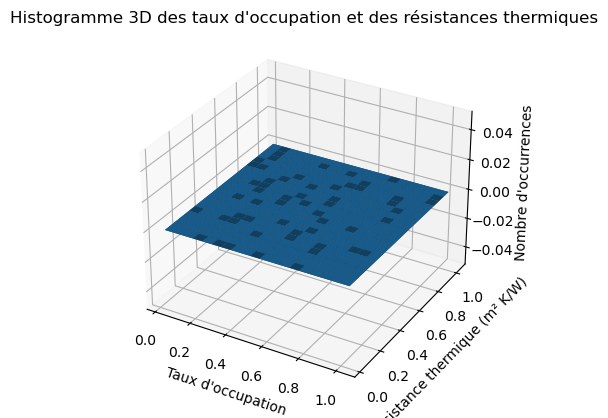

In [151]:
# Paramètres de simulation
num_simulations = 2  # Nombre de répétitions pour chaque nombre de bulles
Nb_values = np.arange(200, 701, 5)  # Valeurs du nombre de bulles de 200 à 700 par incréments de 50

occupation_rates = []
resistances = []

# Effectuer les simulations
for Nb in Nb_values:
    for _ in range(num_simulations):
        occupation_rate, rth = simulate(Nb)
        occupation_rates.append(occupation_rate)
        resistances.append(rth)

# Convertir en numpy arrays pour faciliter la manipulation
occupation_rates = np.array(occupation_rates)
resistances = np.array(resistances)

# Créer l'histogramme 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Définir les bines pour les histogrammes
bins = np.linspace(0, 1, 20)

hist, xedges, yedges = np.histogram2d(occupation_rates, resistances, bins=bins)

# Construire les positions x, y, z pour les barres
xpos, ypos = np.meshgrid(xedges[:-1] + 0.5 * (xedges[1] - xedges[0]),
                         yedges[:-1] + 0.5 * (yedges[1] - yedges[0]), indexing="ij")

xpos = xpos.ravel()
ypos = ypos.ravel()
zpos = 0

# La hauteur des barres
dz = hist.ravel()

# Largeur et profondeur des barres
dx = dy = (bins[1] - bins[0])

ax.bar3d(xpos, ypos, zpos, dx, dy, dz, zsort='average', cmap='viridis')

ax.set_xlabel('Taux d\'occupation')
ax.set_ylabel('Résistance thermique (m² K/W)')
ax.set_zlabel('Nombre d\'occurrences')

plt.title('Histogramme 3D des taux d\'occupation et des résistances thermiques')
plt.show()
